# Notebook Structure
1. Import Libraries
2. Load Engineered Dataset
3. Prepare Data
4. Train Random Forest Model
5. Cross Validation
6. Feature Importance
7. Permutation Importance
8. Prediction Reliability
9. Business Insights
10. Save Final Model

In [1]:
# import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Dataset
df = pd.read_csv("../output/insurance_with_bmi.csv")

In [3]:
# Prepare Data
X = df.drop("PremiumPrice", axis=1)
y = df["PremiumPrice"]

In [6]:
# Split the dataset into features and target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='r2')

print("Cross-Validation R² Scores:", cv_scores)
print("Mean R² Score:", np.mean(cv_scores))
print("Standard Deviation of R² Scores:", np.std(cv_scores))

Cross-Validation R² Scores: [0.59324911 0.88615288 0.80083056 0.70299787 0.68921214]
Mean R² Score: 0.7344885081114017
Standard Deviation of R² Scores: 0.10039275569340597


In [7]:
# Feature Importance of Random Forest 
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Age,0.618922
3,AnyTransplants,0.095502
6,Weight,0.085925
10,BMI,0.054768
4,AnyChronicDiseases,0.037926
9,NumberOfMajorSurgeries,0.035694
5,Height,0.030771
8,HistoryOfCancerInFamily,0.022666
2,BloodPressureProblems,0.009113
1,Diabetes,0.005543


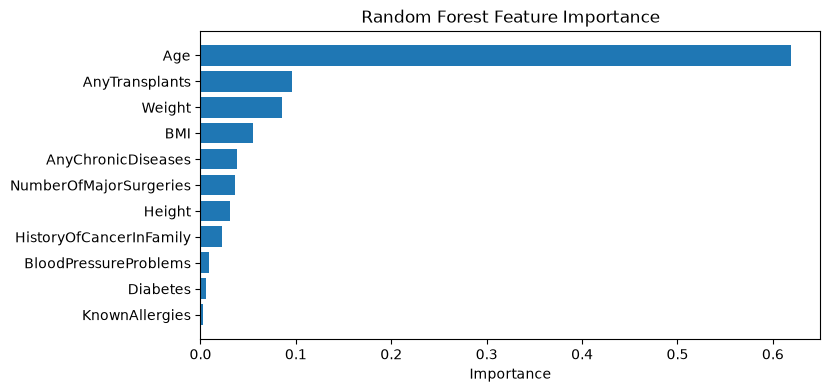

In [9]:
# Plot the importance
plt.figure(figsize=(8,4))
plt.barh(importance["Feature"], importance["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [10]:
# Permutation Importance
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)

perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm.importances_mean
})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
)

perm_df

,Feature,Importance
0,Age,1.138644
3,AnyTransplants,0.217992
6,Weight,0.121293
4,AnyChronicDiseases,0.089212
8,HistoryOfCancerInFamily,0.050543
9,NumberOfMajorSurgeries,0.028485
10,BMI,0.026840
2,BloodPressureProblems,0.025877
5,Height,0.000637
1,Diabetes,0.000231


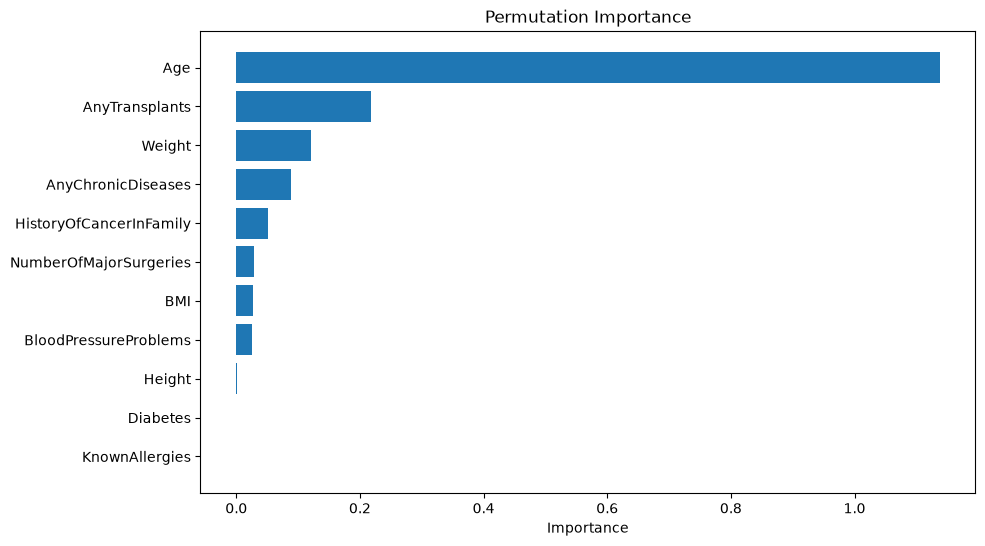

In [11]:
plt.figure(figsize=(10,6))

plt.barh(
    perm_df["Feature"],
    perm_df["Importance"]
)

plt.title("Permutation Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [12]:
# Prediction Reliability
predictions = rf.predict(X_test)
residuals = y_test - predictions
residual_std = residuals.std()
print("Residual Standard Deviation:", residual_std)

Residual Standard Deviation: 2140.549447726765


In [13]:
# Approximate 95% prediction interval
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

results["Lower_95"] = (
    results["Predicted"] - 1.96 * residual_std
)

results["Upper_95"] = (
    results["Predicted"] + 1.96 * residual_std
)

results.head()

,Actual,Predicted,Lower_95,Upper_95
0,31000,29750.0,25554.523082,33945.476918
1,31000,30150.0,25954.523082,34345.476918
2,29000,30230.0,26034.523082,34425.476918
3,15000,16570.0,12374.523082,20765.476918
4,23000,23100.0,18904.523082,27295.476918


# Business Insights

## Objective

The Random Forest model and permutation importance analysis were used to identify the factors that have the greatest influence on insurance premium prediction. Understanding these factors helps insurance companies make better pricing decisions and improve risk assessment.

## Key Business Insights

### 1. Age is the Most Important Risk Factor

Age is the strongest predictor of insurance premium, with the highest permutation importance score (1.1386). This indicates that insurance premiums increase significantly with age, making age the primary factor in premium pricing.

### 2. Transplant History Significantly Increases Premiums

Customers with a history of organ transplants have the second-highest feature importance (0.2180). This suggests that transplant history is a major indicator of health risk and has a substantial impact on insurance costs.

### 3. Weight Contributes More Than BMI

Weight (0.1213) has a greater influence on premium prediction than the engineered BMI feature (0.0268). Although BMI was retained because it is medically meaningful, the model found Weight to be a stronger predictor in this dataset.

### 4. Chronic Diseases Increase Insurance Risk

The presence of chronic diseases (0.0892) is an important contributor to premium prediction. Customers with long-term medical conditions generally require higher insurance coverage, resulting in increased premiums.

### 5. Family Cancer History Has a Moderate Influence

A family history of cancer (0.0505) contributes moderately to premium prediction, indicating that hereditary health risks are considered during premium estimation.

### 6. Previous Major Surgeries Affect Premium Pricing

The number of major surgeries (0.0285) has a measurable influence on insurance premiums, suggesting that customers with extensive surgical histories are associated with higher insurance risk.

### 7. Blood Pressure Problems Have a Small but Positive Impact

Blood pressure problems (0.0259) contribute to premium prediction, although their impact is smaller compared with age, transplant history, and chronic diseases.

### 8. Height, Diabetes, and Known Allergies Have Minimal Influence

Height (0.0006), Diabetes (0.0002), and Known Allergies (-0.0009) have little or no practical influence on the Random Forest model's predictions. Their low importance suggests that they contribute relatively little additional predictive information after the model has already considered the stronger predictors.

## Business Recommendations

- Prioritise age and transplant history during risk assessment because they are the strongest drivers of premium prediction.
- Incorporate chronic diseases and surgical history into premium pricing strategies to improve pricing accuracy.
- Continue collecting high-quality medical history data, as these variables significantly improve prediction performance.
- Review variables with very low predictive importance (such as Height and KnownAllergies) before deploying future models, as they may have limited value in premium estimation for this dataset.

## Conclusion

The permutation importance analysis demonstrates that demographic factors, particularly **Age**, together with major medical history variables such as **AnyTransplants**, **Weight**, and **AnyChronicDiseases**, are the most influential predictors of insurance premium prices. These insights can help insurance companies improve risk assessment, develop fairer pricing strategies, and support data-driven decision-making.

In [14]:
# Save the model
joblib.dump(
    rf,
    "../models/random_forest_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.
